# Notebook 8: Generative Models — VAE and DDPM Diffusion
**UCU Deep Learning Course**

In Notebook 7 we built a decoder-only transformer that **generates text** by sampling one token at a time from a learned distribution over the next character. That was already a generative model — but a *sequential, autoregressive* one. In this notebook we step into two very different ways of modelling a data distribution, both for **images**:

1. **Variational Autoencoders (VAEs)** — encode an image to a low-dimensional Gaussian latent, decode back, and train with the **ELBO** (reconstruction + KL).
2. **Denoising Diffusion Probabilistic Models (DDPM)** — corrupt an image with Gaussian noise over $T$ steps, then train a U-Net to undo the corruption one step at a time.

Both will be built **from scratch** in plain PyTorch on **MNIST** (28×28 digits). At the end of the lab you should be able to look at samples from both models side-by-side and *see* the trade-off the lecture talked about — VAE samples are blurry but the model gives you a meaningful latent code; DDPM samples are sharp but cost $T$ forward passes to generate.

### What you'll learn

1. Implement a **Gaussian VAE** — encoder, **reparameterization trick**, Bernoulli decoder, and the **ELBO** loss (BCE reconstruction + closed-form KL).
2. **Sample** from the VAE prior and **interpolate** between two real images in latent space.
3. Implement DDPM's **forward noising process** using the closed-form marginal $q(z_t\mid x)$.
4. Build a small **U-Net** with sinusoidal time embedding and train it with the noise-prediction MSE objective.
5. Implement the **DDPM reverse sampling loop** and visualize the denoising trajectory.
6. Compare VAE and DDPM samples on the same dataset — connecting back to lecture §6's trade-off table.
7. *(Optional)* Run a pretrained DDPM from HuggingFace **`diffusers`**, swap the scheduler from DDPM to DDIM, and see the ~20× speedup at similar quality.

### References

| Topic | Link |
|-------|------|
| Lecture 9 notes | `../../lectures/lecture 9/notes.md` |
| *Auto-Encoding Variational Bayes* (Kingma & Welling, 2013) | https://arxiv.org/abs/1312.6114 |
| *Denoising Diffusion Probabilistic Models* (Ho et al., 2020) | https://arxiv.org/abs/2006.11239 |
| HuggingFace `diffusers` | https://huggingface.co/docs/diffusers/index |
| `torch.distributions` | https://docs.pytorch.org/docs/stable/distributions.html |
| `torchvision.utils.make_grid` | https://docs.pytorch.org/vision/stable/generated/torchvision.utils.make_grid.html |

> **Heads-up.** The VAE is light and trains fine on CPU. The DDPM has a small U-Net but still needs ~10–15 minutes on **MPS / CUDA**; on CPU it will be substantially slower — reduce `epochs` or `T` if you are CPU-only.


---

## Part 0 — Setup

Imports, seeds, and device selection. We follow the same `cuda → mps → cpu` pattern as Notebooks 6–7.


In [2]:
# Colab-friendly install (skipped if already available)
try:
    import torchinfo  # noqa: F401
except ImportError:
    %pip install -q torchinfo


In [3]:
from __future__ import annotations

import math
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchinfo import summary

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# UCU color palette
C1, C2, C3 = "#19326E", "#50ACB0", "#CD742A"
C4, C5, C6, C7 = "#A3477F", "#907FAB", "#4294CC", "#89A943"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("WARNING: training the DDPM U-Net on CPU is slow.")
    print("         Consider lowering ddpm_epochs or T below if you are on CPU.")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.11.0+cu128


---

## Part 1 — Data: MNIST (~5 min)

We use **MNIST**: 60k train + 10k test 28×28 grayscale handwritten digits. This is the *first* time MNIST appears in this series — its sibling FashionMNIST has been the running benchmark through Notebooks 0–4. Digits are visually unambiguous in a way that fashion items are not, which makes the difference between blurry VAE samples and sharp DDPM samples obvious to the eye.

We deliberately do **not** standardise to mean/std: the Bernoulli VAE decoder in Part 2 wants pixels in $[0, 1]$, and the DDPM in Part 3 will apply its own rescaling to $[-1, 1]$ inside its training loop.


In [4]:
transform = transforms.ToTensor()  # pixels in [0, 1]
data_root = "./data"

train_set = datasets.MNIST(data_root, train=True, download=True, transform=transform)
test_set = datasets.MNIST(data_root, train=False, download=True, transform=transform)

batch_size: int = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train set: {len(train_set):,} images")
print(f"Test set : {len(test_set):,} images")
print(f"Image shape: {train_set[0][0].shape}, pixel range: [{train_set[0][0].min():.2f}, {train_set[0][0].max():.2f}]")


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 361kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Train set: 60,000 images
Test set : 10,000 images
Image shape: torch.Size([1, 28, 28]), pixel range: [0.00, 1.00]


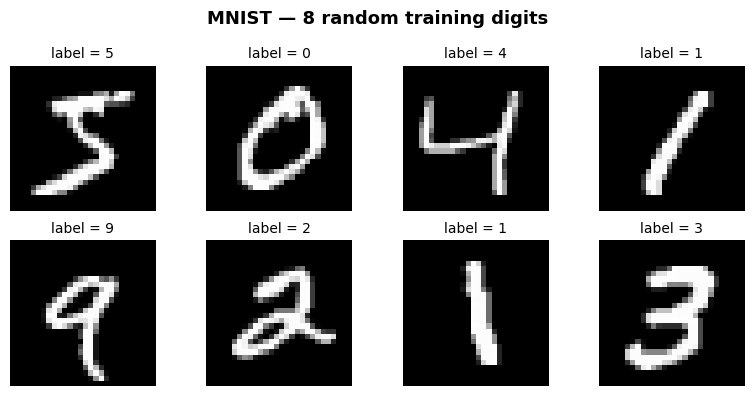

In [5]:
# Provided visualization: a few training digits
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, (img, label) in zip(axes.flat, [train_set[i] for i in range(8)]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"label = {label}", fontsize=10)
    ax.axis("off")
plt.suptitle("MNIST — 8 random training digits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 2 — Variational Autoencoder (~35 min)

Lecture §2 derived the VAE objective by writing the log-likelihood as

$$
\log p_{\boldsymbol\phi}(\mathbf{x}) \;=\; \underbrace{\mathbb{E}_{q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})}\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{reconstruction}}
\;-\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p(\mathbf{z})\bigr]}_{\text{KL regularizer}}
\;+\; D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,p_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\bigr].
$$

The last term is the gap between our **variational posterior** $q$ and the true (intractable) posterior. It is always $\ge 0$, so the first two terms form a **lower bound** on the log-likelihood — the **ELBO**. We maximise the ELBO; equivalently, we minimise its negative:

$$
\mathcal{L} \;=\; \underbrace{-\mathbb{E}_q\!\bigl[\log p_{\boldsymbol\phi}(\mathbf{x}\mid\mathbf{z})\bigr]}_{\text{recon loss}} \;+\; \underbrace{D_{\mathrm{KL}}\!\bigl[q_{\boldsymbol\theta}(\mathbf{z}\mid\mathbf{x})\,\Vert\,\mathcal{N}(0,\mathbf{I})\bigr]}_{\text{closed-form KL}}.
$$

Two technical facts we will use:

- For a Bernoulli decoder over pixels in $[0, 1]$, the negative log-likelihood is **binary cross-entropy**. We work with logits and use `F.binary_cross_entropy_with_logits` for numerical stability (same lesson as `CrossEntropyLoss` on logits in Notebooks 4–7).
- For a diagonal-Gaussian encoder $q(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\boldsymbol\mu, \mathrm{diag}(\boldsymbol\sigma^2))$ against a standard-normal prior, the KL has a **closed form**:

  $$
  D_{\mathrm{KL}}\!\bigl[\mathcal{N}(\boldsymbol\mu, \boldsymbol\sigma^2)\,\Vert\,\mathcal{N}(0, \mathbf{I})\bigr]
  \;=\; -\tfrac{1}{2}\sum_d \bigl(1 + \log\sigma_d^2 - \mu_d^2 - \sigma_d^2\bigr).
  $$

We parameterise the encoder to output `log(sigma^2)` (`logvar`) rather than `sigma` directly — this keeps the variance positive without a constraint and makes the KL formula above plug in cleanly.


### Exercise 2.1 — The VAE class

Implement the `VAE` class:

- `encoder = nn.Sequential(Linear(784, 400), ReLU())`
- `fc_mu = nn.Linear(400, z_dim)` and `fc_logvar = nn.Linear(400, z_dim)` — two separate heads
- `decoder = nn.Sequential(Linear(z_dim, 400), ReLU(), Linear(400, 784))` — returns **logits**, *not* probabilities
- `reparameterize(mu, logvar)`: compute `std = (0.5 * logvar).exp()`, draw `eps ~ N(0, I)` with `torch.randn_like(std)`, return `mu + std * eps`
- `forward(x)`: flatten the image, encode, reparameterize, decode; return `(logits, mu, logvar)`

Use `z_dim=16` as the default.


In [6]:
class VAE(nn.Module):
    def __init__(self, x_dim: int = 784, h_dim: int = 400, z_dim: int = 16):
        super().__init__()
        self.x_dim = x_dim
        self.z_dim = z_dim

        # YOUR CODE HERE — define self.encoder, self.fc_mu, self.fc_logvar, self.decoder
        self.encoder = nn.Sequential(
            nn.Linear(x_dim, h_dim),
            nn.ReLU()
        )

        # heads de salida para los parámetros de la distribución normal
        self.fc_mu = nn.Linear(h_dim, z_dim)    # Media
        self.fc_logvar = nn.Linear(h_dim, z_dim)    # Log varianza (log(sigma^2))

        # Decodificador (que reconstruye la imagen a partir del vector z)
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, x_dim)
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # YOUR CODE HERE — run encoder, return (mu, logvar)
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE — implement the reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE — return logits (no sigmoid)
        return self.decoder(z)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # YOUR CODE HERE — flatten x, encode, reparameterize, decode; return (logits, mu, logvar)
        x_flat = x.flatten(start_dim = 1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


In [7]:
# Sanity check on shapes
vae = VAE().to(device)
x_sample, _ = next(iter(train_loader))
x_sample = x_sample.to(device)
logits, mu, logvar = vae(x_sample)
print(f"logits: {tuple(logits.shape)}")
print(f"mu    : {tuple(mu.shape)}")
print(f"logvar: {tuple(logvar.shape)}")
summary(vae, input_size=(1, 1, 28, 28), depth=2)


logits: (128, 784)
mu    : (128, 16)
logvar: (128, 16)


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 784]                  --
├─Sequential: 1-1                        [1, 400]                  --
│    └─Linear: 2-1                       [1, 400]                  314,000
│    └─ReLU: 2-2                         [1, 400]                  --
├─Linear: 1-2                            [1, 16]                   6,416
├─Linear: 1-3                            [1, 16]                   6,416
├─Sequential: 1-4                        [1, 784]                  --
│    └─Linear: 2-3                       [1, 400]                  6,800
│    └─ReLU: 2-4                         [1, 400]                  --
│    └─Linear: 2-5                       [1, 784]                  314,384
Total params: 648,016
Trainable params: 648,016
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.65
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 2.59
Estimated T

### Exercise 2.2 — The ELBO loss

Implement `elbo_loss(logits, x, mu, logvar, beta=1.0)`:

- **Reconstruction loss**: `F.binary_cross_entropy_with_logits(logits, x.view(B, -1), reduction='sum')`. Using `reduction='sum'` (over batch *and* pixels) and then dividing the final total by the batch size gives a per-image loss whose magnitude is comparable to the KL — a common pattern.
- **KL term**: closed-form, `kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum()`
- Return `(total, recon, kl)`, all averaged over batch (i.e. divide each by `B`).
- The `beta` argument scales the KL term — leave it at `1.0` for the vanilla VAE. (We will play with `beta` in the optional extension.)


In [8]:
def elbo_loss(
    logits: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # YOUR CODE HERE — compute recon (BCE-with-logits, summed over pixels, mean over batch)
    # and kl (closed-form, mean over batch). Return (total, recon, kl).

    # Obtener el batch size
    B = x.size(0)

    # Loss de reconstrucción (sumada en pixeles y promediada en el batch)
    recon = F.binary_cross_entropy_with_logits(logits, x.flatten(start_dim = 1), reduction = "sum") / B

    # Loss KL (formula analitica promediada en el batch)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B

    # Loss total ponderada con beta
    total = recon + beta * kl

    return total, recon, kl


> **Question 2.1** — Why do we use `binary_cross_entropy_with_logits` instead of computing `sigmoid` followed by `binary_cross_entropy`? Mathematically the two are identical.


Respuesta

Cuando se aplica sigmoide a números muy grandes (positivos o negativos), la salida se pueve volver muy cercana a 1 o a 0. Esto puede terminar en problemas de precisión, que llevarían a desvanecimiento de gradientes, ya que la salida de la sigmoide queda tan cerca de 0 o 1, que el gradiente de la sigmoide se hace muy chico, haciendo que los gradientes sean cada vez más chicos en la backpropagation.

Otro problema sería la inestabilidad numérica, ya que podría haber problemas con el uso del logaritmo. Ya que si una probabilidad es tomada como 0 o 1, podría llevar a valores NaN o gradientes muy grandes y inestables.


> **Question 2.2** — Suppose you set the KL coefficient to 0 (i.e. drop the regularizer entirely). What does the model degenerate into, and what would the unconditional samples look like?

Si el coeficiente KL se pusiera en 0, el VAE se degeneraría en un Autoencoder estándar. El modelo solo se enfocaría en la reconstrucción de la entrada, sin regularizar el espacio de z para que se pareciera a una distribución gaussiana normal.

Luego por ese cambio, las muestras obtenidas al muestrear directamente del prior $N(0,I)$ y pasarlas por el decodificador serían solo ruido y imagenes distorsionadas. Eso ya que el decodificador no estaría entrenado para interpretar el espacio de z.

### Exercise 2.3 — Train the VAE

Reusable training helpers are provided below. Your job: pick the hyperparameters (suggested: `epochs=15`, `lr=1e-3`, Adam), run training, and record `(total, recon, kl)` for both train and test sets per epoch.


In [9]:
def train_vae_epoch(
    model: VAE,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.train()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        total.backward()
        optimizer.step()
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


@torch.no_grad()
def evaluate_vae(
    model: VAE,
    loader: DataLoader,
    device: torch.device,
    beta: float = 1.0,
) -> tuple[float, float, float]:
    model.eval()
    total_sum = recon_sum = kl_sum = 0.0
    n = 0
    for x, _ in loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        total, recon, kl = elbo_loss(logits, x, mu, logvar, beta=beta)
        bs = x.size(0)
        total_sum += total.item() * bs
        recon_sum += recon.item() * bs
        kl_sum += kl.item() * bs
        n += bs
    return total_sum / n, recon_sum / n, kl_sum / n


In [10]:
# YOUR CODE HERE — initialize VAE, Adam (lr=1e-3, suggested), train for epochs=15 (suggested).
# Record train and test (total, recon, kl) per epoch in a `history` dict.

vae_epochs = 15
lr = 1e-3

# Inicialzar el modelo y mover a device
vae = VAE(z_dim = 16).to(device)

# Adam con parámetros del VAE
optimizer = torch.optim.Adam(vae.parameters(), lr = lr)

# Diccionario para métricas
history = {
    "train_total": [], "train_recon": [], "train_kl": [],
    "test_total": [], "test_recon": [], "test_kl": []
}

print(f"Entrenamiento en {device}")

for epoch in range(vae_epochs):
  tr_total, tr_recon, tr_kl = train_vae_epoch(vae, train_loader, optimizer, device)

  te_total, te_recon, te_kl = evaluate_vae(vae, test_loader, device)

  history["train_total"].append(tr_total)
  history["train_recon"].append(tr_recon)
  history["train_kl"].append(tr_kl)
  history["test_total"].append(te_total)
  history["test_recon"].append(te_recon)
  history["test_kl"].append(te_kl)

  print(f"Época [{epoch+1}/{vae_epochs}] | "
          f"Test Loss: {te_total:.2f} (Recon: {te_recon:.1f}, KL: {te_kl:.1f})")


Entrenamiento en cuda
Época [1/15] | Test Loss: 126.36 (Recon: 106.1, KL: 20.3)
Época [2/15] | Test Loss: 116.23 (Recon: 94.1, KL: 22.1)
Época [3/15] | Test Loss: 112.69 (Recon: 90.2, KL: 22.5)
Época [4/15] | Test Loss: 110.60 (Recon: 88.0, KL: 22.6)
Época [5/15] | Test Loss: 109.41 (Recon: 86.3, KL: 23.1)
Época [6/15] | Test Loss: 108.50 (Recon: 85.1, KL: 23.4)
Época [7/15] | Test Loss: 107.76 (Recon: 84.5, KL: 23.2)
Época [8/15] | Test Loss: 107.46 (Recon: 83.7, KL: 23.8)
Época [9/15] | Test Loss: 106.93 (Recon: 83.8, KL: 23.1)
Época [10/15] | Test Loss: 106.63 (Recon: 82.8, KL: 23.8)
Época [11/15] | Test Loss: 106.16 (Recon: 82.8, KL: 23.4)
Época [12/15] | Test Loss: 105.91 (Recon: 82.5, KL: 23.4)
Época [13/15] | Test Loss: 105.67 (Recon: 81.9, KL: 23.8)
Época [14/15] | Test Loss: 105.60 (Recon: 81.8, KL: 23.8)
Época [15/15] | Test Loss: 105.23 (Recon: 81.6, KL: 23.7)


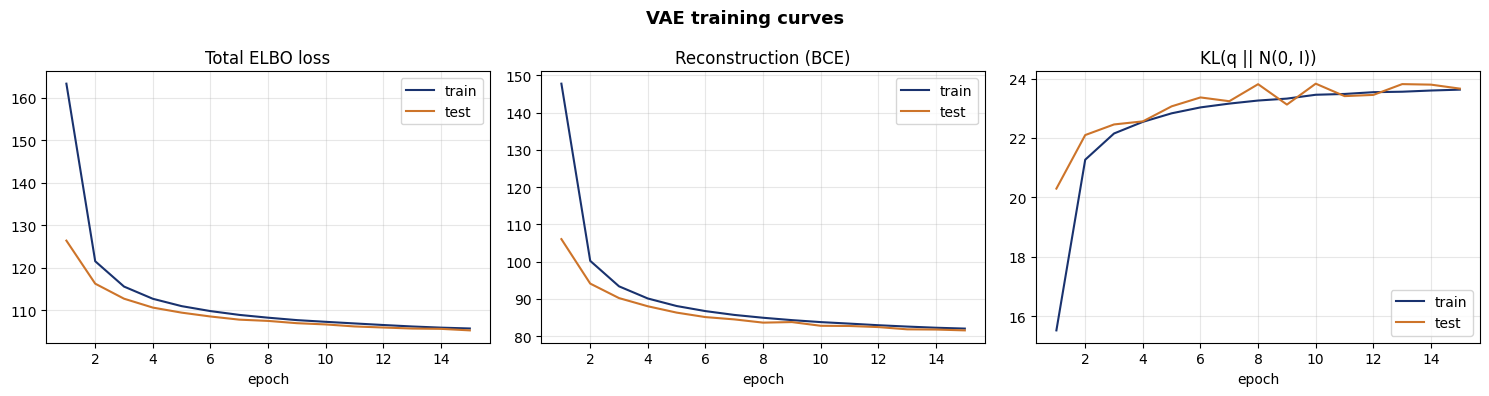

In [11]:
# Provided plot: total / recon / KL vs epoch
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_axis = range(1, vae_epochs + 1)

axes[0].plot(epochs_axis, history["train_total"], label="train", color=C1)
axes[0].plot(epochs_axis, history["test_total"], label="test", color=C3)
axes[0].set_title("Total ELBO loss"); axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, history["train_recon"], label="train", color=C1)
axes[1].plot(epochs_axis, history["test_recon"], label="test", color=C3)
axes[1].set_title("Reconstruction (BCE)"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_axis, history["train_kl"], label="train", color=C1)
axes[2].plot(epochs_axis, history["test_kl"], label="test", color=C3)
axes[2].set_title("KL(q || N(0, I))"); axes[2].set_xlabel("epoch"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE training curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.4 — Sample from the prior

Implement `vae_sample(model, n_samples=16, z_dim=16)`:

1. Draw `z ~ N(0, I)` of shape `(n_samples, z_dim)` on the right device.
2. Decode to logits.
3. Apply `sigmoid` to get probabilities (= image pixel intensities).
4. Reshape to `(n_samples, 1, 28, 28)` and return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [12]:
@torch.no_grad()
def vae_sample(model: VAE, n_samples: int = 16, z_dim: int = 16) -> torch.Tensor:
    # YOUR CODE HERE — draw z ~ N(0, I), decode, sigmoid, reshape to (n, 1, 28, 28). Return on CPU.

    # Ruido aleatorio z siguiendo una normal estandar
    # n_samples vectores, cada uno con z_dim dimensiones
    z = torch.randn(n_samples, z_dim).to(device)

    # Pasar vectores por decoder para obtener los logits
    logits = model.decode(z)

    # Pasar logits a probabilidades con sigmoide
    probs = torch.sigmoid(logits)

    # Reshape de 784 a (n_samples, 1, 28, 28)
    return probs.view(n_samples, 1, 28, 28).cpu()


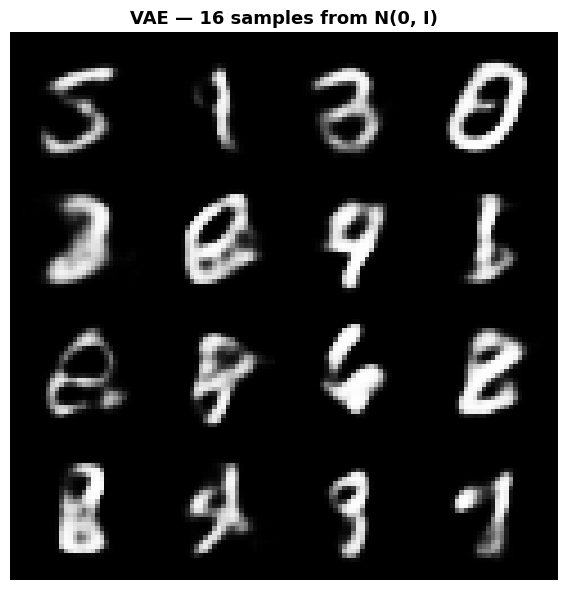

In [13]:
vae_samples = vae_sample(vae, n_samples=16)
grid = make_grid(vae_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — 16 samples from N(0, I)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Exercise 2.5 — Latent-space interpolation

A trained VAE should give a *smooth* latent space: walking in a straight line between two codes should produce a smooth sequence of plausible images. Implement `vae_interpolate(model, x1, x2, n_steps=8)`:

1. Encode `x1` and `x2` with the model's `encode` method and take their **means** (`mu`) — ignore the variance.
2. Linearly interpolate between the two `mu` vectors at `n_steps` evenly spaced values of $\alpha\in[0, 1]$.
3. Decode each interpolated code, sigmoid, return as a `(n_steps, 1, 28, 28)` CPU tensor.

For input, take a `0` and a `9` from the test set.


In [16]:
@torch.no_grad()
def vae_interpolate(
    model: VAE,
    x1: torch.Tensor,
    x2: torch.Tensor,
    n_steps: int = 8,
) -> torch.Tensor:
    # YOUR CODE HERE — encode x1, x2; linearly interpolate the mu vectors; decode each; sigmoid.
    # Return shape (n_steps, 1, 28, 28) on CPU.

    # preparar imagenes y moverlas al device
    x1, x2 = x1.to(device).view(1, -1), x2.to(device).view(1, -1)

    # Obtener vectores de mu
    mu1, _ = model.encode(x1)
    mu2, _ = model.encode(x2)

    # Crear los pesos de interpolación (alpha) de 0 a 1
    alphas = torch.linspace(0, 1, steps = n_steps).to(device)

    # Interpolación lineal, z = (1 - alpha) * mu1 + alpha * mu2, generando n_steps vectores intermedios
    z_interp = (1 - alphas.view(-1, 1)) * mu1 + alphas.view(-1, 1) * mu2

    # Decoder, sigmoide
    logits = model.decode(z_interp)
    probs = torch.sigmoid(logits)

    return probs.view(n_steps, 1, 28, 28).cpu()


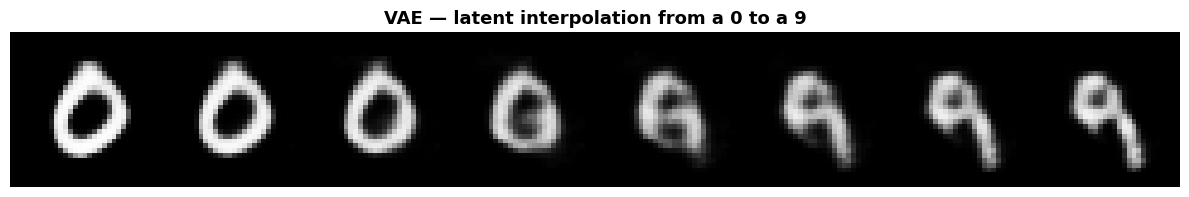

In [17]:
# Pick a 0 and a 9 from the test set
def find_first(label: int) -> torch.Tensor:
    for img, lbl in test_set:
        if lbl == label:
            return img
    raise RuntimeError(f"No example of class {label} in test set")

x_a = find_first(0)
x_b = find_first(9)

interp = vae_interpolate(vae, x_a, x_b, n_steps=8)
grid = make_grid(interp, nrow=8, padding=2).permute(1, 2, 0)
plt.figure(figsize=(12, 2))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("VAE — latent interpolation from a 0 to a 9", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Part 3 — DDPM diffusion model (~50 min)

DDPM ([Ho et al., 2020](https://arxiv.org/abs/2006.11239)) takes a completely different angle. There is no learned encoder — the **forward (encoding) process is fixed**: gradually add Gaussian noise over $T$ steps until any image becomes pure noise. The only thing we *learn* is the **reverse** process — undoing one noising step at a time.

The forward step is

$$
q(\mathbf{z}_t \mid \mathbf{z}_{t-1}) \;=\; \mathcal{N}\!\bigl(\sqrt{1-\beta_t}\,\mathbf{z}_{t-1},\;\beta_t\mathbf{I}\bigr),\qquad \mathbf{z}_0 \equiv \mathbf{x}.
$$

A small bit of algebra (Prince §18.3) gives the **closed-form marginal**:

$$
q(\mathbf{z}_t \mid \mathbf{x}) \;=\; \mathcal{N}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x},\;(1-\bar\alpha_t)\,\mathbf{I}\bigr),\qquad \bar\alpha_t = \prod_{s=1}^t (1 - \beta_s).
$$

This is the practical magic: we can sample any $\mathbf{z}_t$ from $\mathbf{x}$ in **one step**, without simulating the chain.

The training objective, after a bunch of cancellations, reduces to

$$
\mathcal{L} \;=\; \mathbb{E}_{t,\,\mathbf{x},\,\boldsymbol\varepsilon}\!\left[\bigl\|\boldsymbol\varepsilon \;-\; \mathbf{f}_{\boldsymbol\phi}\!\bigl(\sqrt{\bar\alpha_t}\,\mathbf{x} + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon,\;t\bigr)\bigr\|^2\right]
$$

— a **plain MSE on noise prediction**. There is no adversary, no Jacobian, no ELBO gap to worry about. This simplicity is one of the main reasons diffusion has won.


### Exercise 3.1 — Build the noise schedule

Build the three buffers we will need throughout the rest of Part 3, on the right `device`:

- `betas = torch.linspace(1e-4, 0.02, T)` for `T = 1000`
- `alphas = 1.0 - betas`
- `alpha_bar = torch.cumprod(alphas, dim=0)`


In [ ]:
T: int = 1000
# YOUR CODE HERE — build `betas`, `alphas`, `alpha_bar` on `device`.
raise NotImplementedError()


### Exercise 3.2 — `q_sample`: one-shot forward noising

Implement `q_sample(x0, t, noise=None)`:

- `x0` shape `(B, 1, 28, 28)`, on `device`.
- `t` shape `(B,)` of integer timesteps in `[0, T-1]`.
- `noise` shape `(B, 1, 28, 28)` or `None` — if `None`, sample standard normal noise.
- Look up `alpha_bar[t]` and **reshape** it to `(B, 1, 1, 1)` so it broadcasts over the image axes.
- Return $\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\varepsilon$.


In [ ]:
def q_sample(
    x0: torch.Tensor,
    t: torch.Tensor,
    noise: torch.Tensor | None = None,
) -> torch.Tensor:
    # YOUR CODE HERE — sample z_t from x0 in one step using the closed-form marginal.
    raise NotImplementedError()


In [ ]:
# Provided visualization: one digit at increasing levels of noise
img, _ = test_set[0]                            # shape (1, 28, 28), pixels in [0, 1]
x0 = (img.to(device) * 2 - 1).unsqueeze(0)      # rescale to [-1, 1] and add batch dim
ts = [0, 50, 200, 500, 999]
noisy = []
torch.manual_seed(0)
for t_val in ts:
    t = torch.tensor([t_val], device=device)
    z_t = q_sample(x0, t)
    noisy.append(z_t.squeeze(0).cpu())

fig, axes = plt.subplots(1, len(ts), figsize=(2.5 * len(ts), 2.8))
for ax, t_val, img_t in zip(axes, ts, noisy):
    ax.imshow(((img_t.clamp(-1, 1) + 1) / 2).squeeze(), cmap="gray")
    ax.set_title(f"t = {t_val}", fontsize=11)
    ax.axis("off")
plt.suptitle("Forward process — q(z_t | x) at increasing t", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### The U-Net: backbone of the reverse process

The reverse process predicts the noise that was added to produce $\mathbf{z}_t$. Its input is an image $\mathbf{z}_t$ (shape `(B, 1, 28, 28)`) plus the timestep $t$, and its output is the same shape as the input. The standard choice is a **U-Net**:

- Encoder convs downsample the spatial dimensions.
- Decoder convs upsample back, **with skip connections from the matching encoder resolution** (same as Notebook 6).
- The timestep is injected as a **sinusoidal embedding** projected through a small MLP and added to feature maps at every block.

The `SinusoidalTimeEmb` and `ResBlock` modules below are **provided** — you do not need to modify them. Your job is to assemble them into a `SmallUNet`.


In [ ]:
class SinusoidalTimeEmb(nn.Module):
    """Standard sinusoidal positional encoding for the diffusion timestep."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: shape (B,) integer timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """GroupNorm + SiLU conv block with timestep injection and a residual connection."""

    def __init__(self, in_c: int, out_c: int, t_emb_dim: int):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_c)
        self.t_proj = nn.Linear(t_emb_dim, out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_c)
        self.skip = nn.Conv2d(in_c, out_c, kernel_size=1) if in_c != out_c else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.act(self.norm1(self.conv1(x)))
        # broadcast time embedding across H, W
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


### Exercise 3.3 — `SmallUNet`

Here is a version of the U-Net using the building blocks above. The layout is as follows (with `base = 32`, `t_emb_dim = 128`):

- **Time MLP**: `SinusoidalTimeEmb(t_emb_dim) → Linear(t_emb_dim, t_emb_dim*4) → SiLU → Linear(t_emb_dim*4, t_emb_dim*4)`. Pass the result of the time MLP as `t_emb` to every `ResBlock`. (So `t_emb_dim` consumed by `ResBlock` is `t_emb_dim * 4`.)
- **Stem**: `Conv2d(1, base, 3, padding=1)`.
- **Encoder**:
  - `ResBlock(base, base, t_emb_dim*4)`, save output as skip `s1`.
  - Downsample: `nn.Conv2d(base, base, 4, stride=2, padding=1)` → 28 → 14.
  - `ResBlock(base, base*2, t_emb_dim*4)`, save output as skip `s2`.
  - Downsample: `nn.Conv2d(base*2, base*2, 4, stride=2, padding=1)` → 14 → 7.
- **Bottleneck**: `ResBlock(base*2, base*4, t_emb_dim*4)`.
- **Decoder**:
  - Upsample: `nn.ConvTranspose2d(base*4, base*2, 4, stride=2, padding=1)` → 7 → 14.
  - Concatenate with `s2` along the channel dim, then `ResBlock(base*4, base*2, t_emb_dim*4)`.
  - Upsample: `nn.ConvTranspose2d(base*2, base, 4, stride=2, padding=1)` → 14 → 28.
  - Concatenate with `s1`, then `ResBlock(base*2, base, t_emb_dim*4)`.
- **Head**: `Conv2d(base, 1, 3, padding=1)` — predicts the noise (same shape as input).


In [ ]:
class SmallUNet(nn.Module):
    def __init__(self, base: int = 32, t_emb_dim: int = 128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(t_emb_dim),
            nn.Linear(t_emb_dim, t_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(t_emb_dim * 4, t_emb_dim * 4),
        )
        td = t_emb_dim * 4

        # Stem
        self.stem = nn.Conv2d(1, base, kernel_size=3, padding=1)
        # Encoder
        self.enc1 = ResBlock(base, base, td)
        self.down1 = nn.Conv2d(base, base, kernel_size=4, stride=2, padding=1)
        self.enc2 = ResBlock(base, base * 2, td)
        self.down2 = nn.Conv2d(base * 2, base * 2, kernel_size=4, stride=2, padding=1)
        # Bottleneck
        self.mid = ResBlock(base * 2, base * 4, td)
        # Decoder
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ResBlock(base * 4, base * 2, td)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=4, stride=2, padding=1)
        self.dec1 = ResBlock(base * 2, base, td)
        # Head
        self.head = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)

        h = self.stem(x)
        s1 = self.enc1(h, t_emb)
        h = self.down1(s1)
        s2 = self.enc2(h, t_emb)
        h = self.down2(s2)
        h = self.mid(h, t_emb)
        h = self.up2(h)
        h = self.dec2(torch.cat([h, s2], dim=1), t_emb)
        h = self.up1(h)
        h = self.dec1(torch.cat([h, s1], dim=1), t_emb)
        return self.head(h)


In [ ]:
# Sanity check on shapes and parameter count
unet = SmallUNet().to(device)
x_dummy = torch.randn(4, 1, 28, 28, device=device)
t_dummy = torch.randint(0, T, (4,), device=device)
out = unet(x_dummy, t_dummy)
print(f"input : {tuple(x_dummy.shape)}")
print(f"output: {tuple(out.shape)}")
n_params = sum(p.numel() for p in unet.parameters())
print(f"U-Net parameters: {n_params:,}")


> **Question 3.1** — Why are **skip connections** essential in a diffusion U-Net? (Hint: think about what the output has to look like, not what the bottleneck stores.)


> **Question 3.2** — Why do we **add** the time embedding inside every residual block instead of just concatenating it once to the input image?


### Exercise 3.4 — The training objective

Implement `diffusion_loss(model, x0, T)`:

1. Rescale `x0` from `[0, 1]` to `[-1, 1]` (standard DDPM practice — gives zero mean).
2. Sample timesteps `t ~ U{0, T-1}` of shape `(B,)`.
3. Sample noise `eps ~ N(0, I)` of shape `(B, 1, 28, 28)`.
4. Compute `z_t = q_sample(x0_rescaled, t, noise=eps)`.
5. Run the model: `eps_hat = model(z_t, t)`.
6. Return `F.mse_loss(eps_hat, eps)`.


In [ ]:
def diffusion_loss(model: nn.Module, x0: torch.Tensor, T: int) -> torch.Tensor:
    # YOUR CODE HERE — implement the noise-prediction MSE objective. Rescale x0 to [-1, 1] first.
    raise NotImplementedError()


### Exercise 3.5 — Train the DDPM

Train the U-Net. Suggested: `ddpm_epochs = 20`, `lr = 2e-4`, `AdamW`. Record the loss per epoch.


In [ ]:
# YOUR CODE HERE — initialize SmallUNet, AdamW (lr=2e-4), train for ddpm_epochs=20.
# Record the per-epoch loss in `ddpm_losses`.
raise NotImplementedError()


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, ddpm_epochs + 1), ddpm_losses, color=C2, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("DDPM noise-prediction loss", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Exercise 3.6 — DDPM reverse sampling

The DDPM reverse step (Ho et al. 2020, equation (11)) is

$$
\mathbf{z}_{t-1} \;=\; \frac{1}{\sqrt{\alpha_t}}\!\left(\mathbf{z}_t \;-\; \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\varepsilon_{\boldsymbol\phi}(\mathbf{z}_t, t)\right) \;+\; \sigma_t\,\boldsymbol\xi,
$$

with $\sigma_t^2 = \beta_t$ and $\boldsymbol\xi\sim\mathcal{N}(0,\mathbf{I})$ for $t > 0$, and no noise added at the final step ($t = 0$).

Implement `ddpm_sample(model, n_samples, T)`:

1. Start `z = torch.randn(n_samples, 1, 28, 28, device=device)`.
2. For `t` from `T-1` down to `0`:
   - Build `t_batch = torch.full((n_samples,), t, ...)`.
   - Predict noise `eps_hat = model(z, t_batch)`.
   - Compute the mean update.
   - If `t > 0`, add `sqrt(beta_t) * noise` where `noise ~ N(0, I)`.
3. After the loop, rescale `z` from `[-1, 1]` back to `[0, 1]` and clamp.
4. Return as a CPU tensor.

Wrap the body in `@torch.no_grad()`.


In [ ]:
@torch.no_grad()
def ddpm_sample(
    model: nn.Module,
    n_samples: int,
    T: int,
    track_every: int | None = None,
) -> tuple[torch.Tensor, list[torch.Tensor]]:
    # YOUR CODE HERE — implement the DDPM reverse loop.
    # If track_every is given, snapshot the (rescaled, CPU) tensor every `track_every` steps.
    # Return (final_samples_in_[0,1], trajectory_list).
    raise NotImplementedError()


In [ ]:
ddpm_samples, _ = ddpm_sample(unet, n_samples=16, T=T)
grid = make_grid(ddpm_samples, nrow=4, padding=2).permute(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("DDPM — 16 unconditional samples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Provided: visualize the reverse process for a single sample
torch.manual_seed(7)
_, traj = ddpm_sample(unet, n_samples=1, T=T, track_every=T // 8)
# `traj` is collected from t = T-1 down to t = 0 — show in that order
fig, axes = plt.subplots(1, len(traj), figsize=(2 * len(traj), 2.5))
for ax, img_t in zip(axes, traj):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
axes[0].set_title("pure noise", fontsize=10)
axes[-1].set_title("final sample", fontsize=10)
plt.suptitle("DDPM reverse process — one sample, 8 evenly-spaced timesteps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 3.3** — Sampling 16 images cost you 16 × `T` = **16,000** U-Net forward passes. Compare this with the VAE — how many forward passes did `vae_sample(model, n_samples=16)` cost? What does this say about which model you would deploy in a real-time system?


---

## Part 4 — Side-by-side comparison (~10 min)


In [ ]:
vae_compare = vae_sample(vae, n_samples=8)
ddpm_compare, _ = ddpm_sample(unet, n_samples=8, T=T)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, img_t in zip(axes[0], vae_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
for ax, img_t in zip(axes[1], ddpm_compare):
    ax.imshow(img_t.squeeze(), cmap="gray", vmin=0, vmax=1); ax.axis("off")
axes[0, 0].set_ylabel("VAE",  fontsize=12, rotation=0, labelpad=30); axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel("DDPM", fontsize=12, rotation=0, labelpad=30); axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
plt.suptitle("Same dataset, two generative models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 4.1** — Describe **one visible failure mode of the VAE** and **one visible failure mode of the DDPM** in your samples.
>
> **Question 4.2** — Map each model onto the (likelihood, sample quality, sampling speed) triangle from lecture §6. For each of the following deployments, which model would you pick and why?
>
> - (a) Anomaly detection on factory-floor camera images.
> - (b) Generating a high-resolution marketing avatar.
> - (c) Compressing handwritten digits into a 16-dimensional code for a downstream classifier.


---

## Part 5 — Optional: HuggingFace `diffusers` with a tiny pretrained model (~25 min)

We just built a 28×28 MNIST diffusion model. Production diffusion models share the *same math* (β schedule, U-Net, noise prediction) but are pretrained on millions of images at much higher resolution, with conditional inputs (text, class), classifier-free guidance, and faster samplers.

[`diffusers`](https://huggingface.co/docs/diffusers/index) is HuggingFace's library for these models. It packages everything — the U-Net, the scheduler (DDPM, DDIM, …), the conditional inputs — into a `Pipeline` object with a single `__call__` API. We use a **tiny pretrained model** (`google/ddpm-cifar10-32`, 32×32 CIFAR-10) so the download is small and inference works on any hardware (CPU is slow but feasible; MPS/CUDA is comfortable). Stable Diffusion would teach the same lesson but needs ~6 GB of VRAM and a much larger download.


In [ ]:
try:
    from diffusers import DDPMPipeline, DDIMScheduler  # noqa: F401
except ImportError:
    %pip install -q diffusers accelerate
    from diffusers import DDPMPipeline, DDIMScheduler


### Exercise O.1 — Pretrained DDPM pipeline

Load `google/ddpm-cifar10-32`, move it to `device`, and sample 4 images with the default DDPM scheduler (1000 inference steps). Time the call. Display the four samples in a row.


In [ ]:
# YOUR CODE HERE — load `google/ddpm-cifar10-32`, sample 4 images with the default
# DDPM scheduler (num_inference_steps=1000), time the call, display the samples.
raise NotImplementedError()


### Exercise O.2 — Swap the scheduler to DDIM

`diffusers` lets you swap the **scheduler** without retraining the U-Net. **DDIM** reformulates the reverse process as a deterministic ODE that can be solved in many fewer steps.

Swap `pipe.scheduler` to a DDIM scheduler built from the same config, re-sample 4 images with `num_inference_steps=50`, time it, and display. (The U-Net weights are unchanged — only the integration scheme.)


In [ ]:
# YOUR CODE HERE — swap pipe.scheduler to a DDIM scheduler from the same config,
# re-sample with num_inference_steps=50, time the call, display.
raise NotImplementedError()


> **Question O.1** — Did the DDIM samples look meaningfully worse with **20× fewer steps**? Connect this to the ODE / deterministic-reformulation note in lecture §5.3.
> **Question O.2** — If you wanted to fine-tune `pipe.unet` on, say, 1000 custom logos at 32×32, what would you change in the pipeline you just used? (No code — just describe.)


---

## Done!

You've built two complete generative models from scratch on the same dataset and seen — visually — the trade-off the lecture spent a whole table on. A few things worth noting before you close the notebook:

- The **VAE** was light, stable, gave you a meaningful 16-d code, and produced blurry but recognisable digits.
- The **DDPM** was heavier to train and *much* slower to sample, but the samples are crisp and there is no encoder–decoder gap.
- The optional `diffusers` section gave you a feel for the production toolchain: the same math, packaged so that swapping the sampler from DDPM to DDIM is a one-line change.
- The other two families from the lecture — **GANs** and **normalizing flows** — are conceptually similar exercises if you want to keep going on your own.

Next lecture moves from generation to **reinforcement learning**, where the data distribution is shaped by the agent's own actions — a closing topic that ties together perception, modelling, and decision-making.
